In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
df = pd.read_excel("medical_insurance.xlsx")

In [27]:
# 1-ci hissə — Dataset analizi
print("First 10 Rows",df.head(10))
print("Last 10 Rows\n",df.tail(10))
print("Dataset Shape\n",df.shape)
print("Columns\n",df.columns)
print("Data Type\n",df.dtypes)
print("Statics\n",df.describe(include='all'))
print("Missing Values\n",df.isnull().sum())
print("Duplicate Rows\n",df.duplicated().sum())

First 10 Rows    Age  Height_cm  Weight_kg   BMI  Smoker  ExercisePerWeek  ChronicDisease  \
0   58        157         48  19.5       0                3               1   
1   65        156        114  46.8       1                6               1   
2   23        163         74  27.9       1                3               0   
3   46        187         80  22.9       1                2               0   
4   35        159         72  28.5       0                1               1   
5   24        172         89  30.1       0                0               0   
6   25        174         55  18.2       0                5               1   
7   22        152        129  55.8       1                4               1   
8   24        174         80  26.4       0                5               1   
9   40        163        130  48.9       0                1               1   

   InsuranceCost_AZN  
0               3286  
1               9776  
2               4747  
3               4864  
4

Age                  0
Height_cm            0
Weight_kg            0
BMI                  0
Smoker               0
ExercisePerWeek      0
ChronicDisease       0
InsuranceCost_AZN    0
dtype: int64
Age                  0
Height_cm            0
Weight_kg            0
BMI                  0
Smoker               0
ExercisePerWeek      0
ChronicDisease       0
InsuranceCost_AZN    0
dtype: int64


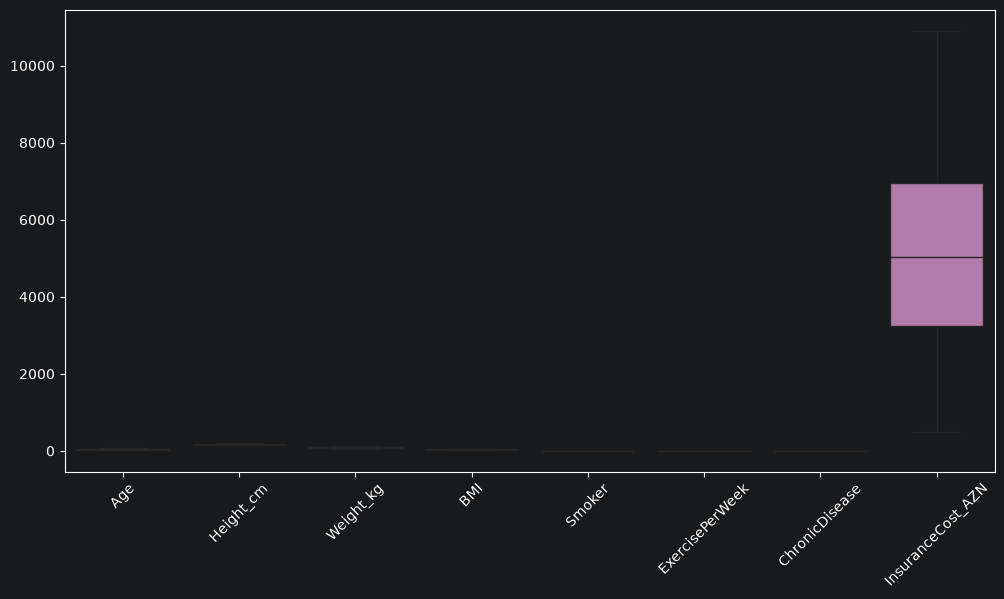

Dataset olcusu (500, 8)
   Age  Height_cm  Weight_kg   BMI  Smoker  ExercisePerWeek  ChronicDisease  \
0   58        157         48  19.5       0                3               1   
1   65        156        114  46.8       1                6               1   
2   23        163         74  27.9       1                3               0   
3   46        187         80  22.9       1                2               0   
4   35        159         72  28.5       0                1               1   

   InsuranceCost_AZN  
0               3286  
1               9776  
2               4747  
3               4864  
4               4259  


In [29]:
# 2-ci hissə — Data Cleaning

# Boş dəyərləri yoxla
print(df.isnull().sum())


# Boş dəyərləri doldur
numeric_columns  = df.select_dtypes(include=np.number).columns

for col in numeric_columns :
    df[col] = df[col].fillna(df[col].median())

cat_col = df.select_dtypes(include=['object','string']).columns

for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

# Outlier analizi

plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()

Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~(
        ((df[numeric_columns] < (Q1 - 1.5 * IQR)) |
         (df[numeric_columns] > (Q3 + 1.5 * IQR)))
    ).any(axis=1)
]
print("Dataset olcusu",df.shape)

# Categorical sütunları model üçün uyğun formata çevir

encoder = LabelEncoder()

cat_columns = df.select_dtypes(include=['object', 'string']).columns

for col in cat_columns:
    df[col] = encoder.fit_transform(df[col])
print(df.head())

In [30]:
# 3-cü hissə — Feature və Target seçimi
target = "InsuranceCost_AZN"
X = df.drop(target,axis =1)
y=df[target]

# 4-cü hissə — Train/Test bölünməsi
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 5-ci hissə — Decision Tree Regressor
params = {
    "criterion": ["squared_error", "absolute_error", "poisson"],
    "max_depth": [3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

dt = DecisionTreeRegressor(random_state=42)

grid_dt = GridSearchCV(
    dt,
    params,
    cv=5,
    scoring="r2"
)

grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)


{'criterion': 'poisson', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [31]:
best_dt = grid_dt.best_estimator_

prediction_dt = best_dt.predict(X_test)

mae = mean_absolute_error(y_test,prediction_dt)
mse = mean_squared_error(y_test,prediction_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,prediction_dt)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 356.94398809523807
MSE: 181032.04945606104
RMSE: 425.4786122192995
R2: 0.9664810919290472


In [32]:
# 7-ci hissə — Random Forest Regressor
params_rf = {

    "n_estimators":[100,200,300],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2"]
}

rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(
    rf,
    params_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [33]:
best_rf = grid_rf.best_estimator_
prediction_rf = best_rf.predict(X_test)

mae = mean_absolute_error(y_test,prediction_rf)
mse = mean_squared_error(y_test,prediction_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,prediction_rf)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 289.21105937098105
MSE: 129778.83785592651
RMSE: 360.24830028180077
R2: 0.9759708573773634


In [34]:
# 9-cu hissə — Modellərin müqayisəsi
comparison = pd.DataFrame({
    "Model":["Decision Tree","Random Forest"],
    "MAE":[
        mean_absolute_error(y_test,prediction_dt),
        mean_absolute_error(y_test,prediction_rf)
    ],
    "MSE":[
        mean_squared_error(y_test,prediction_dt),
        mean_squared_error(y_test,prediction_rf)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,prediction_dt)),
        np.sqrt(mean_squared_error(y_test,prediction_rf))
    ],
    "R2":[
        r2_score(y_test,prediction_dt),
        r2_score(y_test,prediction_rf)
    ]
})

print(comparison)

           Model         MAE            MSE        RMSE        R2
0  Decision Tree  356.943988  181032.049456  425.478612  0.966481
1  Random Forest  289.211059  129778.837856  360.248300  0.975971


           Feature  Importance
4           Smoker    0.474119
6   ChronicDisease    0.164887
3              BMI    0.132439
2        Weight_kg    0.104938
1        Height_cm    0.053924
0              Age    0.044424
5  ExercisePerWeek    0.025269


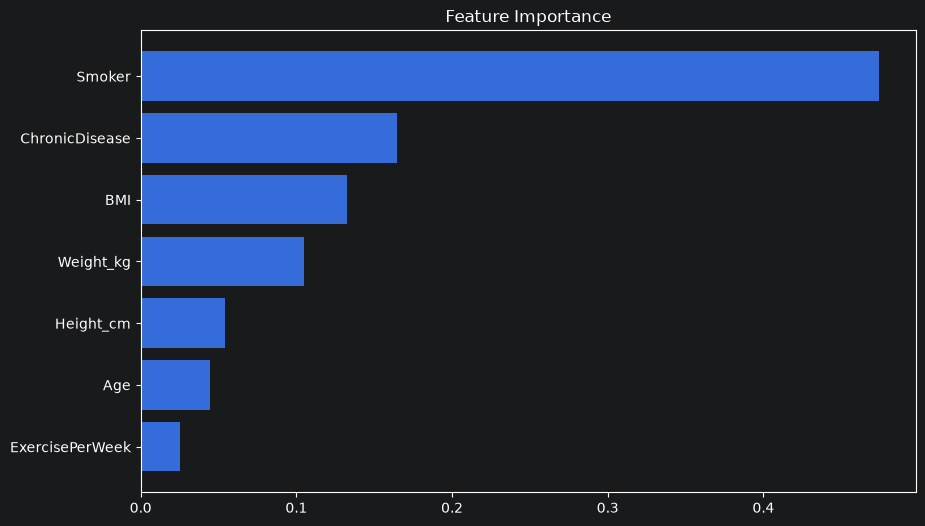

Head:
           Feature  Importance
4          Smoker    0.474119
6  ChronicDisease    0.164887
3             BMI    0.132439
Tail:
            Feature  Importance
5  ExercisePerWeek    0.025269


In [35]:
# 10-cu hissə — Feature Importance
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_

})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

# Qrafik

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

# Ən vacib 3 feature
print("Head:\n",importance.head(3))

# Ən az təsir edən
print("Tail:\n",importance.tail(1))

In [36]:
# 11-ci hissə — Yeni müştəri üçün proqnoz
new_customer = pd.DataFrame({
    "Age": [58],
    "Height_cm": [157],
    "Weight_kg": [48],
    "BMI": [19.5],
    "Smoker": [0],
    "ExercisePerWeek": [3],
    "ChronicDisease": [1]
})


prediction = best_rf.predict(new_customer)

print("InsuranceCost_AZN:",prediction)

InsuranceCost_AZN: [3852.20053341]


# Analiz Sualları

### 1. Decision Tree necə qərar verir?
Verilənləri xüsusiyyətlərə görə bölərək qərar ağacı qurur və proqnoz verir.

### 2. Random Forest niyə adətən daha yaxşı nəticə verir?
Bir neçə Decision Tree-nin nəticəsini birləşdirdiyi üçün daha dəqiq və sabit olur.

### 3. Random Forest-də ağacların sayı artırıldıqda nə baş verir?
Model adətən daha dəqiq olur, amma işləmə vaxtı artır.

### 4. max_depth çox böyük seçilərsə hansı problem yarana bilər?
Model overfitting edə bilər və test nəticəsi pisləşər.

### 5. min_samples_leaf modelə necə təsir edir?
Böyük seçildikdə model daha sadə olur və overfitting azalır.

### 6. Feature Importance nədir?
Feature-ların modelə təsir dərəcəsini göstərən göstəricidir.

### 7. Ən vacib feature hansıdır və bunun səbəbi nə ola bilər?
Feature Importance nəticəsində ən yüksək dəyərə malik feature. Çünki proqnoza ən çox təsir edir.

### 8. BMI ilə InsuranceCost arasında necə əlaqə müşahidə etdiniz?
Adətən BMI artdıqca InsuranceCost da artır.

### 9. Siqaret çəkmək sığorta qiymətinə necə təsir edir?
Siqaret çəkənlərin sığorta qiyməti daha yüksək olur.

### 10. İdman edən insanların sığorta qiymətində hansı fərqi müşahidə etdiniz?
İdman edənlərin sığorta qiyməti adətən daha aşağı olur.

### 11. Xroniki xəstəlik olan şəxslərin qiymətlərində hansı dəyişiklik var?
Xroniki xəstəliyi olanların sığorta qiyməti daha yüksək olur.

### 12. Siz sığorta şirkətinin Data Scientist-i olsaydınız modeli daha da yaxşılaşdırmaq üçün hansı yeni məlumatları əlavə edərdiniz?
Gəlir səviyyəsi, ailə xəstəlik tarixi, qan təzyiqi, xolesterol, həyat tərzi və qidalanma məlumatlarını əlavə edərdim.